# Network Assignment


- some subjects still dont fully show all nets in parietal ROI/IPS (dorsalAttention, fronto-parietal, cinguloOpercular, DMN) 
- consensus assignment of average for future reference (with Cole-Anticevic Atlas)
- inspect weird subject (10 - 717 vis2-net vertices in NPC)

also adapt 

In [1]:
import nilearn
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op
from brainspace.utils.parcellation import map_to_labels

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
target_folder = op.join(bids_folder,'derivatives','networks_infomap_full')


250929-13:03:16,4 nipype.utils WARNING:
	 A newer version (1.10.0) of nipy/nipype is available. You are using 1.8.6
[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


### For subs with still dont fully show all nets in parietal ROI/IPS

load in

In [ ]:
previous_conn_thresholds = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3]


In [23]:
sub = '15'
sub_module_mappings_relabelled = np.load(f'/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full/sub-{sub}_allThresholds_confspec-36Pscrub3BPfilter.npy')
print(sub_module_mappings_relabelled.shape)

for sub_module_mapping in sub_module_mappings_relabelled:
    print(np.unique(sub_module_mapping))

(6, 18715)
[-1  2  3  9]
[-1  2  9]
[-1  2  3  4  5  9]
[-1  2  3  4  5  9]
[-1  2  3  4  5  9]
[-1  2  3  4  5  9]


In [17]:
# individual subject

source_folder = op.join(bids_folder, 'derivatives', 'correlation_matrices.tryNoHalo') # .parcel
confspec = '36Pscrub3BPfilter'
cm_file = op.join(source_folder,f'sub-{sub}_ses-1_task-magjudge_confspec-{confspec}runFD104-6runs_CM-unfiltered.npy')
cm_f = np.load(cm_file)


In [19]:
from fit_assign_consens_plot_nets import threshold_matrix, spatial_filtering, assign_subject_communities_to_reference
from infomap import Infomap

cm_filtered = spatial_filtering(cm_f, bids_folder=bids_folder)

conn_threshold = 0.005

cm_thresh = threshold_matrix(cm_filtered, proportion=conn_threshold)
N = cm_thresh.shape[0]
im = Infomap(preferred_number_of_modules=None) # add flags like '--two-level' if needed
for i in range(N):
    for j in range(i+1, N):
        w = cm_thresh[i, j]
        if w > 0:
            im.add_link(i, j, w)
im.run()

returned_nodes = np.array([node.node_id for node in im.nodes])
returned_modules = np.array([node.module_id for node in im.nodes])
full_module_mapping = np.full((N,), -1, dtype=int)  # -1 means unassigned
full_module_mapping[returned_nodes] = returned_modules

fn_target_labels_caNets = op.join(target_folder, f'sub-average_consensusMapping_confspec-{confspec}.npy') # mapped to ColeAnticevic nets
target_labels_caNets = np.load(fn_target_labels_caNets)
relabeled_subject, assignments = assign_subject_communities_to_reference(full_module_mapping, target_labels_caNets,  jaccard_threshold=0.1)


[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface
  Infomap v2.8.0 starts at 2025-07-29 13:12:11
  -> Input network: 
  -> No file output!
  OpenMP 201511 detected with 16 threads...
  -> Ordinary network input, using the Map Equation for first order network flows
Calculating global network flow using flow model 'undirected'... 
  -> Using undirected links.
  => Sum node flow: 1, sum link flow: 1
Build internal network with 15605 nodes and 435182 links...
  -> One-level codelength: 13.0924545

Trial 1/1 starting at 2025-07-29 13:12:11
Two-level compression: 18% 1.3% 0.0134686305% 0.13472908% 0.00649679539% 0.00512942473% 
Partitioned to codelength 0.801576437 + 9.71680724 = 10.51838367 in 167 modules.
Super-level compression: 0.787136667% to codelength 10.43558962 in 25 top modules.

Recursive sub-structure compression: 11.6217402% 0.0254163311% 0% . Found 4 levels with codelength 10.41215253

=> Trial 1/1 finished in 2.10543975s with codelength 10.4121525


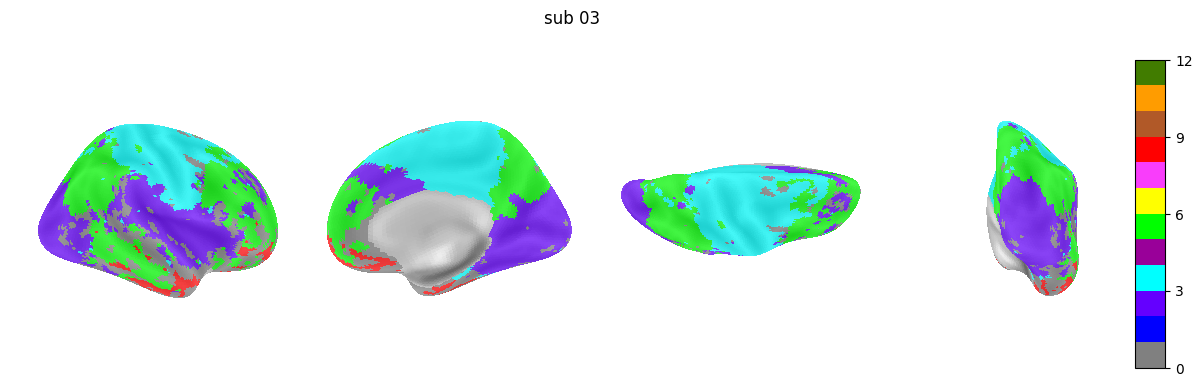

In [21]:
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] = relabeled_subject

from utils import plot_nets_CAcolors
figure = plot_nets_CAcolors(modules_fsav5, hemi_to_plot='R')
figure.suptitle(f'sub {sub}', y=0.75)

plot_folder = op.join(bids_folder,'plots_and_ims','networks_infomap_singleThresh')

plot_fn = op.join(plot_folder, f'sub-{sub}_thresh-{conn_threshold}_networks_infomap_hemi-R_confspec-{confspec}.png')
figure.savefig(plot_fn, dpi=300, bbox_inches='tight')

### inspect weird subject (10 - 717 vis2-net vertices in NPC)



In [2]:
sub = '10'

# look at previous results with old threshold array etc.
source_folder = op.join(bids_folder,'derivatives','networks_infomap_full_01')
all_threshs_module_mappings = np.load(op.join(source_folder,f'sub-{sub}_allThresholds_confspec-36Pscrub3BPfilter.npy'))


In [3]:
all_threshs_module_mappings.shape

(6, 18715)

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


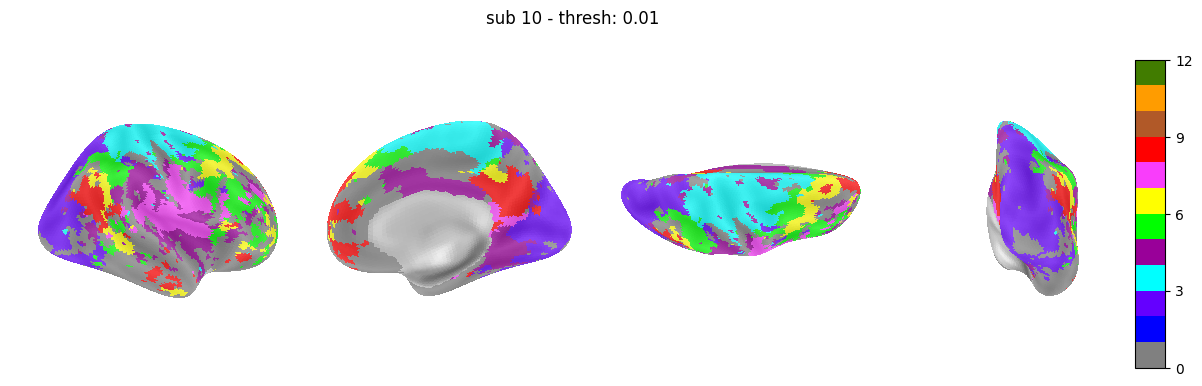

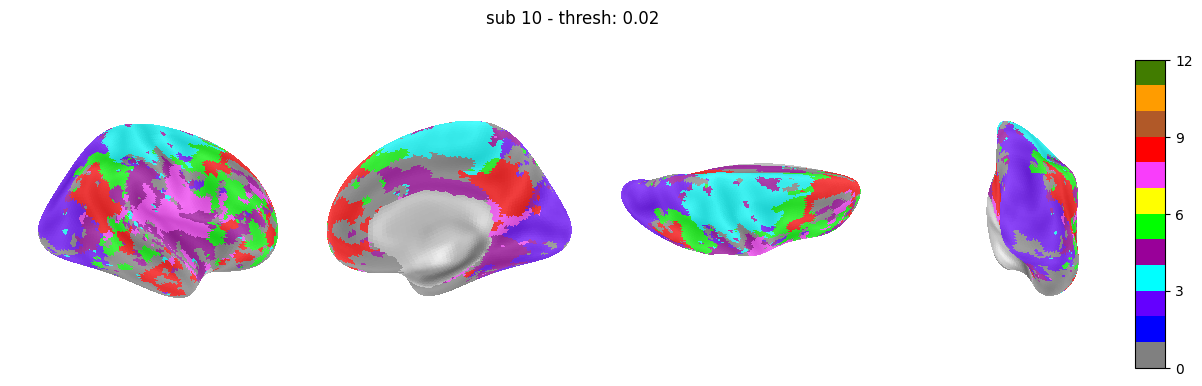

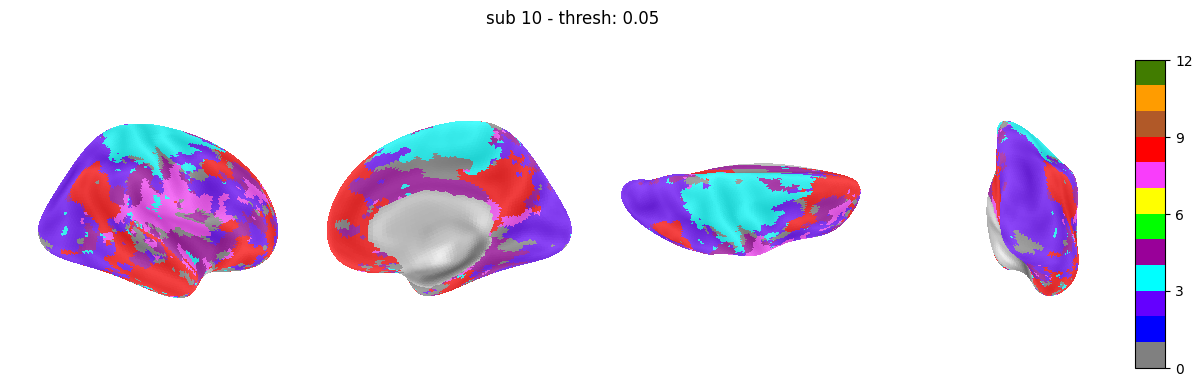

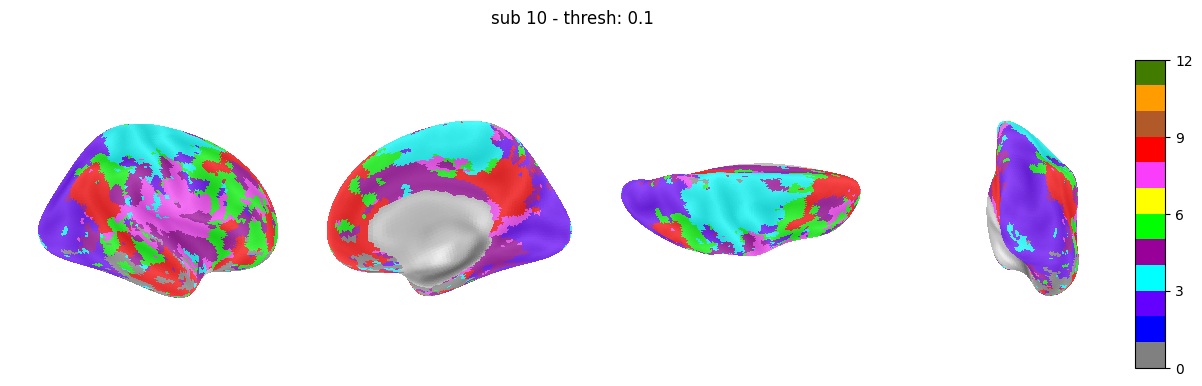

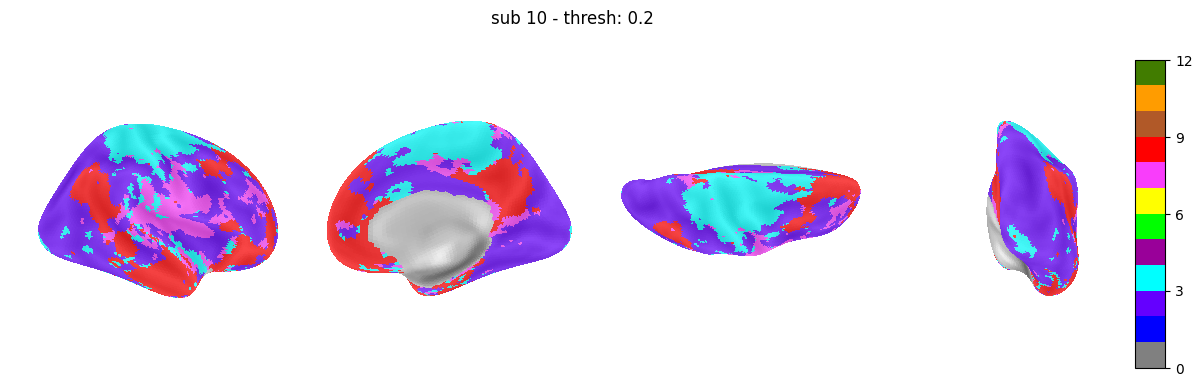

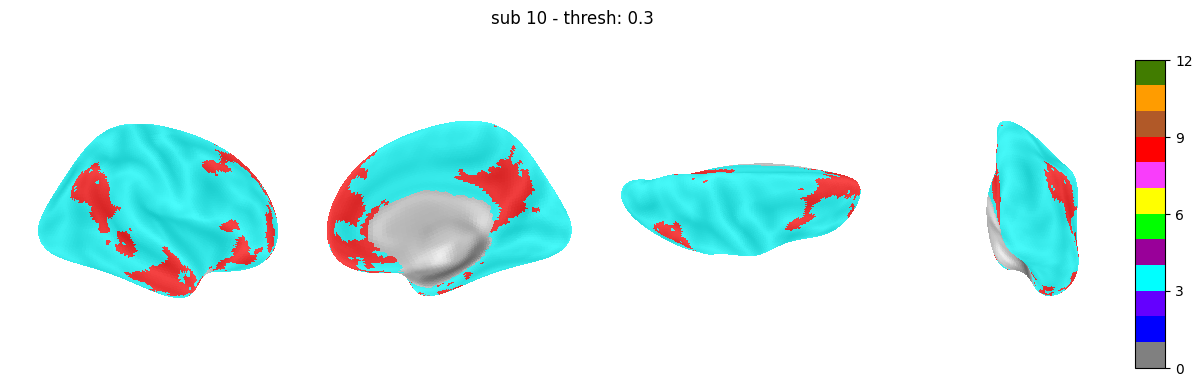

In [6]:
threshs = ['0.01','0.02','0.05','0.1', '0.2', '0.3']

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

from utils import plot_nets_CAcolors

for thresh_conn, mapping in zip(threshs, all_threshs_module_mappings):
    modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
    modules_fsav5[mask] = mapping

    figure = plot_nets_CAcolors(modules_fsav5, hemi_to_plot='R')
    figure.suptitle(f'sub {sub} - thresh: {thresh_conn}', y=0.75)
    #fn_plot = op.join(plot_folder, f'sub-{sub}_thresh-{thresh_conn}.png')
    #plt.savefig(fn_plot)

## Do consenus assignment for average as future reference

In [3]:
# sub-average
sub = 'average'
source_folder = op.join(bids_folder, 'derivatives', 'correlation_matrices.tryNoHalo') # .parcel
confspec = '36Pscrub3BPfilter'
cm_file = op.join(source_folder,f'cm_av_ses-1_fsav5_unfiltered_confspec-{confspec}runFD104.npy')
cm_f = np.load(cm_file)


In [7]:
# target
from numrisk.fmri_analysis.gradients.utils import get_glasser_CAatlas_mapping, get_glasser_parcels
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(glasser_CAatlas_mapping['ca_network'].values , 
                                     labeling_glasser, mask=mask_glasser, fill=0) #, fill=np.nan) #grad_sub[n_grad-1]

target_labels_caNets = caNets_fsav5_mapping[mask]


In [8]:
from fit_assign_consens_plot_nets import threshold_matrix, spatial_filtering, assign_subject_communities_to_reference
from infomap import Infomap

cm_filtered = spatial_filtering(cm_f, bids_folder=bids_folder)

conn_thresholds = [0.03, 0.05, 0.1, 0.2, 0.3 ]
sub_module_mappings_relabelled = []

sub_module_mappings_relabelled = []
for conn_threshold in conn_thresholds:
    cm_thresh = threshold_matrix(cm_filtered, proportion=conn_threshold)
    N = cm_thresh.shape[0]
    im = Infomap(preferred_number_of_modules=None) # add flags like '--two-level' if needed
    for i in range(N):
        for j in range(i+1, N):
            w = cm_thresh[i, j]
            if w > 0:
                im.add_link(i, j, w)
    im.run()

    returned_nodes = np.array([node.node_id for node in im.nodes])
    returned_modules = np.array([node.module_id for node in im.nodes])
    full_module_mapping = np.full((N,), -1, dtype=int)  # -1 means unassigned
    full_module_mapping[returned_nodes] = returned_modules

    relabeled_subject, assignments = assign_subject_communities_to_reference(full_module_mapping, target_labels_caNets,  jaccard_threshold=0.1)
    sub_module_mappings_relabelled.append(relabeled_subject)

fn_mappings = op.join(target_folder, f'sub-{sub}_allThresholds_confspec-{confspec}.npy')
np.save(fn_mappings, np.array(sub_module_mappings_relabelled))


[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface
  Infomap v2.8.0 starts at 2025-07-29 12:44:41
  -> Input network: 
  -> No file output!
  OpenMP 201511 detected with 16 threads...
  -> Ordinary network input, using the Map Equation for first order network flows
Calculating global network flow using flow model 'undirected'... 
  -> Using undirected links.
  => Sum node flow: 1, sum link flow: 1
Build internal network with 16348 nodes and 2359360 links...
  -> One-level codelength: 13.4499122

Trial 1/1 starting at 2025-07-29 12:44:42
Two-level compression: 13% 0.64% 0.00708619748% 0.0279254522% 
Partitioned to codelength 0.563106906 + 11.000361 = 11.56346787 in 54 (52 non-trivial) modules.
Super-level compression: 0.00460985338% to codelength 11.56293481 in 9 top modules.

Recursive sub-structure compression: 9.37912782% 0.280494035% 0% . Found 4 levels with codelength 11.49132288

=> Trial 1/1 finished in 10.954288s with codelength 11.4913229


Summary a

In [11]:
for sub_module_mapping in sub_module_mappings_relabelled:
    print(np.unique(sub_module_mapping))

[-1  3  9]
[-1  2  3  4  5  7  8  9 10 12]
[-1  2  3  4  5  6  7  9]
[-1  2  3  4  7  8  9]
[-1  2  3  7  9 10]


In [ ]:
from fit_assign_consens_plot_nets import get_consensus_assignment
consensus_labels = get_consensus_assignment(sub_module_mappings_relabelled[1:])

In [2]:
sub = 'average'
confspec = '36Pscrub3BPfilter'
target_folder = op.join(bids_folder,'derivatives','networks_infomap_full')
fn_consens_mapping = op.join(target_folder, f'sub-{sub}_consensusMapping_confspec-{confspec}.npy')
consensus_labels = np.load(fn_consens_mapping)

In [3]:
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] = consensus_labels

fn_consens_mapping = op.join(target_folder, f'sub-{sub}_consensusMapping_confspec-{confspec}.npy')
np.save(fn_consens_mapping, np.array(consensus_labels))

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Text(0.5, 0.75, 'sub average')

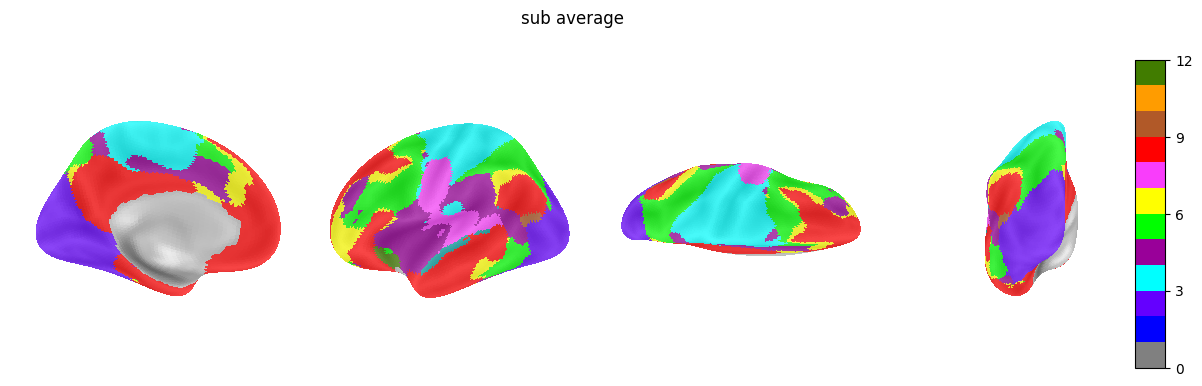

In [4]:
from utils import plot_nets_CAcolors
figure = plot_nets_CAcolors(modules_fsav5, hemi_to_plot='L')
figure.suptitle(f'sub {sub}', y=0.75)
#plot_fn = op.join(plot_folder, f'sub-{sub}_networks_infomap_hemi-R_confspec-{confspec}.png')
#figure.savefig(plot_fn, dpi=300, bbox_inches='tight')